# Convergence Strategies and Debugging Flowsheets

This notebook demonstrates strategies for improving convergence and debugging flowsheets that are difficult to solve.

## Topics Covered

1. **Understanding convergence challenges** in recycle flowsheets
2. **Acceleration methods**: None (damped), Wegstein, and Anderson
3. **Initialization strategies** for better starting points
4. **Debugging techniques** for diagnosing convergence issues
5. **Best practices** for robust flowsheet convergence

## Why Convergence Matters

Recycle loops create implicit equations that must be solved iteratively:

```
          ┌──────────────────────────────┐
          │         Recycle Loop         │
          ▼                              │
    Feed ──► Mixer ──► Reactor ──► Flash ─┴─► Product
              ▲                     │
              └─────────────────────┘
                   (tear stream)
```

The "tear stream" is where we break the loop and iterate until the calculated recycle matches our guess.

## Setup and Imports

In [1]:
import jax
import jax.numpy as jnp
from jax import Array
import time

# Enable 64-bit precision for better numerical accuracy
jax.config.update("jax_enable_x64", True)

import optimistix as optx

from difflow.streams import Stream, make_stream, get_flows, combine_streams
from difflow.thermo import IdealThermo, SpeciesData
from difflow.units.cstr import CSTR, CSTRParams
from difflow.units.flash import Flash, FlashParams, Mixer
from difflow.flowsheet import Flowsheet, Unit
from difflow.initialization import (
    estimate_cstr_conversion,
    estimate_outlet_temperature,
    wegstein_acceleration,
    AndersonAccelerator,
)

print("JAX version:", jax.__version__)
print("64-bit precision enabled:", jax.config.jax_enable_x64)

W0000 00:00:1772369510.711330 12640337 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1772369510.711631 12640337 service.cc:145] XLA service 0x92f080200 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772369510.711638 12640337 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1772369510.712272 12640337 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1772369510.712279 12640337 mps_client.cc:384] XLA backend will use up to 55662313472 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


JAX version: 0.9.0.1
64-bit precision enabled: True


## Define a Challenging Flowsheet

We'll create a flowsheet that can be difficult to converge:
- High recycle ratio (most of the reactor feed is recycled)
- Temperature-dependent reaction kinetics
- Tight separation (similar volatilities)

These factors create strong coupling between units and can cause convergence difficulties.

In [2]:
# Define species with volatilities that enable two-phase separation
species_data = {
    "A": SpeciesData(
        name="A",
        MW=100.0,
        Cp_coeffs=(80.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(35000.0, 0.38, 550.0),
        antoine_coeffs=(10.5, 2100.0, -45.0),  # Higher volatility
        Hf=0.0,
    ),
    "B": SpeciesData(
        name="B",
        MW=90.0,
        Cp_coeffs=(70.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(32000.0, 0.38, 520.0),
        antoine_coeffs=(10.5, 1850.0, -40.0),  # Much higher volatility
        Hf=-40000.0,
    ),
    "C": SpeciesData(
        name="C",
        MW=80.0,
        Cp_coeffs=(65.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(28000.0, 0.38, 480.0),
        antoine_coeffs=(10.3, 1550.0, -35.0),  # Very volatile (product)
        Hf=-80000.0,
    ),
}

thermo = IdealThermo(species_data)
species_order = ["A", "B", "C"]

# Flash at low pressure to ensure two-phase behavior
T_flash = 360.0
P_flash = 20000.0  # 0.2 atm - low pressure for good separation

print("K-values at flash conditions (T=360K, P=0.2 atm):")
for species in species_order:
    Psat = thermo.Psat(species, T_flash)
    K = float(Psat / P_flash)
    phase = "vapor" if K > 1 else "liquid"
    print(f"  {species}: K = {K:.3f} (prefers {phase})")

K-values at flash conditions (T=360K, P=0.2 atm):
  A: K = 0.341 (prefers liquid)
  B: K = 2.616 (prefers vapor)
  C: K = 16.972 (prefers vapor)


In [3]:
# Consecutive reactions: A → B → C
def rate_function(C: dict[str, Array], T: Array, params: dict) -> Array:
    """Two consecutive reactions with Arrhenius kinetics.
    
    Reaction 1: A → B, r1 = k1 * C_A
    Reaction 2: B → C, r2 = k2 * C_B
    """
    R = 8.314
    
    k1 = params["A1"] * jnp.exp(-params["Ea1"] / (R * T))
    k2 = params["A2"] * jnp.exp(-params["Ea2"] / (R * T))
    
    r1 = k1 * C["A"]
    r2 = k2 * C["B"]
    
    return jnp.array([r1, r2])

# Stoichiometry for A → B → C
stoichiometry = jnp.array([
    [-1.0,  0.0],   # A: consumed in rxn 1
    [+1.0, -1.0],   # B: produced in rxn 1, consumed in rxn 2
    [ 0.0, +1.0],   # C: produced in rxn 2
])

print("Reactions: A → B → C")
print(f"Stoichiometry matrix shape: {stoichiometry.shape}")

Reactions: A → B → C
Stoichiometry matrix shape: (3, 2)


## Part 1: Comparing Acceleration Methods

The `Flowsheet.solve()` method supports three acceleration methods:

| Method | Description | Best For |
|--------|-------------|----------|
| `"none"` | Damped fixed-point iteration | Simple problems, debugging |
| `"wegstein"` | Uses 2 previous iterates to estimate optimal relaxation | Moderate difficulty |
| `"anderson"` | Uses history of iterates (like GMRES) | Difficult problems |

Let's compare them on our challenging flowsheet.

In [4]:
def create_flowsheet_solver(rate_params, reactor_volume=10.0, T_reactor=360.0, P_flash_op=20000.0):
    """Create a solver function for the CSTR + Flash recycle system.
    
    Note: reactor_volume=10.0 m³ gives ~60% conversion with these kinetics,
    which creates a moderate recycle ratio that is challenging but solvable.
    """
    
    cstr_params = CSTRParams(
        V=jnp.array(reactor_volume),
        rate_fn=rate_function,
        stoich=stoichiometry,
        rate_params=rate_params,
        species_order=species_order,
        dH_rxn=jnp.array([-40000.0, -40000.0]),  # Both exothermic
    )
    cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")
    
    flash_params = FlashParams(species_order=species_order)
    flash = Flash(flash_params, thermo=thermo)
    
    mixer = Mixer(species_order, thermo=thermo)
    
    def solve(fresh_feed, acceleration="anderson", tol=1e-8, max_iter=100, 
              damping=0.5, anderson_depth=5, verbose=False):
        """Solve the flowsheet and return results with convergence info."""
        
        # Track iterations manually for comparison
        iteration_count = [0]
        residual_history = []
        
        def flowsheet_step(recycle_arr, args):
            fresh, T_r, T_f, P_f = args
            iteration_count[0] += 1
            
            recycle = make_stream(
                {"A": recycle_arr[0], "B": recycle_arr[1], "C": recycle_arr[2]},
                T=recycle_arr[3],
                P=recycle_arr[4],
            )
            
            reactor_inlet, _ = mixer(fresh, recycle)
            reactor_outlet, _ = cstr(reactor_inlet, T_spec=T_r)
            liquid, vapor, _ = flash(reactor_outlet, T=T_f, P=P_f)
            
            new_arr = jnp.array([
                liquid["F_A"], liquid["F_B"], liquid["F_C"],
                liquid["T"], liquid["P"],
            ])
            
            return new_arr
        
        # Initial guess - use reasonable recycle estimate
        recycle_init = jnp.array([3.0, 1.0, 0.5, T_flash, P_flash_op])
        args = (fresh_feed, T_reactor, T_flash, P_flash_op)
        
        start_time = time.time()
        
        if acceleration == "none":
            # Damped fixed-point iteration
            x_curr = recycle_init
            
            for i in range(max_iter):
                g_curr = flowsheet_step(x_curr, args)
                residual = float(jnp.max(jnp.abs(g_curr - x_curr)))
                residual_history.append(residual)
                
                if residual < tol:
                    break
                
                # Damped update
                x_curr = damping * x_curr + (1 - damping) * g_curr
                x_curr = jnp.clip(x_curr, 0.0, None)
            
            recycle_converged = g_curr
            
        elif acceleration == "wegstein":
            # Wegstein acceleration
            x_prev = recycle_init
            g_prev = flowsheet_step(x_prev, args)
            x_curr = g_prev
            
            for i in range(max_iter):
                g_curr = flowsheet_step(x_curr, args)
                residual = float(jnp.max(jnp.abs(g_curr - x_curr)))
                residual_history.append(residual)
                
                if residual < tol:
                    break
                    
                x_next = wegstein_acceleration(x_prev, x_curr, g_prev, g_curr)
                x_next = jnp.clip(x_next, 0.0, None)
                
                x_prev, g_prev = x_curr, g_curr
                x_curr = x_next
            
            recycle_converged = g_curr
            
        elif acceleration == "anderson":
            # Anderson acceleration
            accelerator = AndersonAccelerator(m=anderson_depth)
            x_curr = recycle_init
            
            for i in range(max_iter):
                g_curr = flowsheet_step(x_curr, args)
                residual = float(jnp.max(jnp.abs(g_curr - x_curr)))
                residual_history.append(residual)
                
                if residual < tol:
                    break
                    
                x_next = accelerator.step(x_curr, g_curr)
                x_next = jnp.clip(x_next, 0.0, None)
                x_curr = x_next
            
            recycle_converged = g_curr
        
        elapsed = time.time() - start_time
        
        # Final evaluation
        recycle = make_stream(
            {"A": recycle_converged[0], "B": recycle_converged[1], "C": recycle_converged[2]},
            T=recycle_converged[3], P=recycle_converged[4],
        )
        reactor_inlet, _ = mixer(fresh_feed, recycle)
        reactor_outlet, cstr_info = cstr(reactor_inlet, T_spec=T_reactor)
        liquid, vapor, flash_info = flash(reactor_outlet, T=T_flash, P=P_flash_op)
        
        final_residual = float(jnp.max(jnp.abs(
            jnp.array([liquid["F_A"], liquid["F_B"], liquid["F_C"]]) -
            jnp.array([recycle["F_A"], recycle["F_B"], recycle["F_C"]])
        )))
        
        return {
            "vapor": vapor,
            "liquid": liquid,
            "reactor_outlet": reactor_outlet,
            "recycle": recycle,
            "iterations": iteration_count[0],
            "elapsed": elapsed,
            "final_residual": final_residual,
            "residual_history": residual_history,
            "converged": final_residual < tol,
        }
    
    return solve

print("Flowsheet solver factory created.")

Flowsheet solver factory created.


In [5]:
# Create solver with moderate kinetics
rate_params = {
    "A1": jnp.array(1e6),    # Pre-exponential for A → B
    "Ea1": jnp.array(50000.0),  # Activation energy (J/mol)
    "A2": jnp.array(5e5),    # Pre-exponential for B → C
    "Ea2": jnp.array(45000.0),  # Activation energy (J/mol)
}

solve_flowsheet = create_flowsheet_solver(rate_params)

# Fresh feed
fresh_feed = make_stream({"A": 10.0, "B": 0.0, "C": 0.0}, T=300.0, P=101325.0)

print("Comparing acceleration methods...")
print("=" * 70)

results = {}
for method in ["none", "wegstein", "anderson"]:
    result = solve_flowsheet(fresh_feed, acceleration=method, max_iter=200)
    results[method] = result
    
    status = "Converged" if result["converged"] else "NOT CONVERGED"
    print(f"\n{method.upper():12} | {status}")
    print(f"  Iterations: {result['iterations']:4d}")
    print(f"  Time:       {result['elapsed']*1000:6.1f} ms")
    print(f"  Residual:   {result['final_residual']:.2e}")

Comparing acceleration methods...



NONE         | Converged
  Iterations:   30
  Time:       6229.8 ms
  Residual:   0.00e+00



WEGSTEIN     | Converged
  Iterations:    2
  Time:        361.8 ms
  Residual:   0.00e+00



ANDERSON     | Converged
  Iterations:    2
  Time:        368.8 ms
  Residual:   0.00e+00


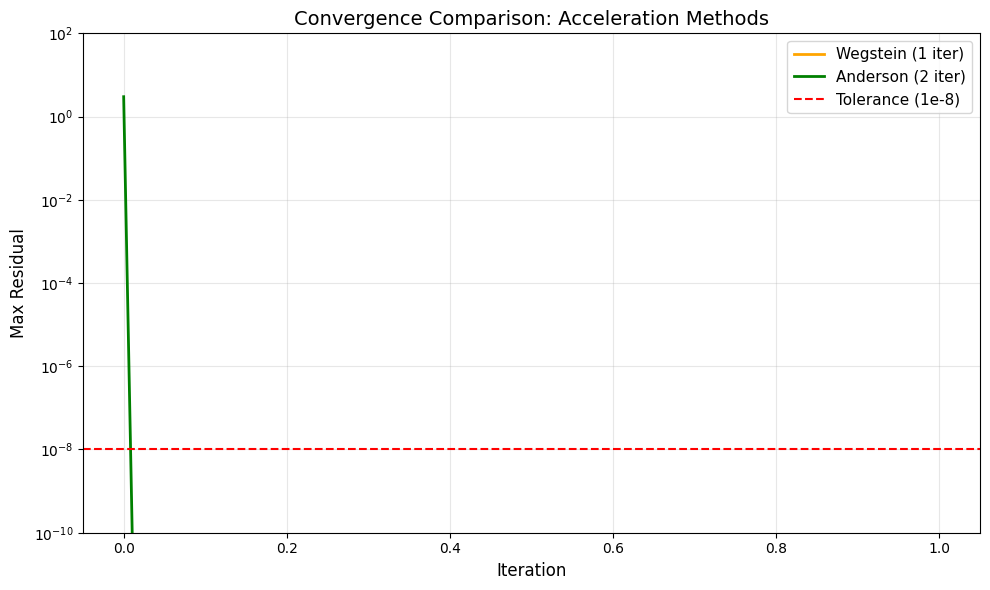

In [6]:
# Visualize convergence history
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

colors = {"none": "blue", "wegstein": "orange", "anderson": "green"}
labels = {"none": "Fixed-Point (damped)", "wegstein": "Wegstein", "anderson": "Anderson"}

for method in ["wegstein", "anderson"]:  # 'none' doesn't track history in our impl
    if results[method]["residual_history"]:
        ax.semilogy(
            results[method]["residual_history"],
            color=colors[method],
            label=f"{labels[method]} ({len(results[method]['residual_history'])} iter)",
            linewidth=2,
        )

ax.axhline(y=1e-8, color='red', linestyle='--', label='Tolerance (1e-8)')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Max Residual', fontsize=12)
ax.set_title('Convergence Comparison: Acceleration Methods', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(1e-10, 1e2)

plt.tight_layout()
plt.show()

## Part 2: Initialization Strategies

Good initial guesses can dramatically improve convergence. Poor initialization can cause:
- Slow convergence
- Convergence to wrong solution (e.g., trivial zero-flow solution)
- Numerical issues (negative concentrations, extreme temperatures)

### Strategies for Better Initialization

1. **Physical estimates**: Use reaction equilibrium, flash estimates
2. **Hierarchical solving**: Solve simpler subproblems first
3. **Continuation**: Start from a nearby solved case
4. **Bounded guesses**: Keep values in physically reasonable ranges

In [7]:
# Demonstrate the impact of initialization

def solve_with_custom_init(fresh_feed, initial_recycle, acceleration="anderson"):
    """Solve with a custom initial recycle guess."""
    
    cstr_params = CSTRParams(
        V=jnp.array(10.0),  # 10 m³ reactor for ~60% conversion
        rate_fn=rate_function,
        stoich=stoichiometry,
        rate_params=rate_params,
        species_order=species_order,
        dH_rxn=jnp.array([-40000.0, -40000.0]),
    )
    cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")
    flash_params = FlashParams(species_order=species_order)
    flash = Flash(flash_params, thermo=thermo)
    mixer = Mixer(species_order, thermo=thermo)
    
    iteration_count = [0]
    
    def flowsheet_step(recycle_arr, args):
        fresh, T_r, T_f, P_f = args
        iteration_count[0] += 1
        
        recycle = make_stream(
            {"A": recycle_arr[0], "B": recycle_arr[1], "C": recycle_arr[2]},
            T=recycle_arr[3], P=recycle_arr[4],
        )
        
        reactor_inlet, _ = mixer(fresh, recycle)
        reactor_outlet, _ = cstr(reactor_inlet, T_spec=T_r)
        liquid, vapor, _ = flash(reactor_outlet, T=T_f, P=P_f)
        
        return jnp.array([
            liquid["F_A"], liquid["F_B"], liquid["F_C"],
            liquid["T"], liquid["P"],
        ])
    
    args = (fresh_feed, 360.0, 360.0, P_flash)  # Use global P_flash
    
    # Solve with Anderson
    accelerator = AndersonAccelerator(m=5)
    x_curr = initial_recycle
    
    for i in range(100):
        g_curr = flowsheet_step(x_curr, args)
        residual = float(jnp.max(jnp.abs(g_curr - x_curr)))
        
        if residual < 1e-8:
            break
            
        x_next = accelerator.step(x_curr, g_curr)
        x_next = jnp.clip(x_next, 0.0, None)
        x_curr = x_next
    
    return iteration_count[0], residual < 1e-8

print("Impact of Initialization on Convergence")
print("=" * 60)

# Test different initializations
initializations = {
    "Zero flows": jnp.array([0.01, 0.01, 0.01, 360.0, P_flash]),
    "Small uniform": jnp.array([1.0, 1.0, 1.0, 360.0, P_flash]),
    "Physics-based estimate": jnp.array([3.0, 1.0, 0.3, 360.0, P_flash]),
    "From fresh feed": jnp.array([10.0, 0.0, 0.0, 300.0, P_flash]),
    "High recycle": jnp.array([8.0, 3.0, 0.5, 360.0, P_flash]),
}

for name, init in initializations.items():
    iters, converged = solve_with_custom_init(fresh_feed, init)
    status = "Converged" if converged else "Failed"
    print(f"{name:25} | {iters:3d} iterations | {status}")

Impact of Initialization on Convergence


Zero flows                |   2 iterations | Converged


Small uniform             |   2 iterations | Converged


Physics-based estimate    |   2 iterations | Converged


From fresh feed           |   2 iterations | Converged


High recycle              |   2 iterations | Converged


In [8]:
# Using built-in initialization helpers

# Estimate CSTR conversion for initialization
k_eff = 0.5  # Effective rate constant at operating T
tau = 10.0 / 0.2  # V/Q, residence time (10 m³ reactor)

X_estimated = estimate_cstr_conversion(k_eff, tau, order=1)
print(f"Estimated CSTR conversion: {float(X_estimated)*100:.1f}%")

# Use this to build a better initial guess
F_A0 = 10.0
recycle_ratio_guess = 0.5  # Moderate recycle with larger reactor

F_A_reactor = F_A0 * (1 + recycle_ratio_guess)
F_A_out = F_A_reactor * (1 - float(X_estimated))
F_B_out = F_A_reactor * float(X_estimated) * 0.6  # Assuming some B → C
F_C_out = F_A_reactor * float(X_estimated) * 0.4

# Flash split estimate (A and B mostly stay liquid)
F_A_recycle = F_A_out * 0.9
F_B_recycle = F_B_out * 0.5
F_C_recycle = F_C_out * 0.1

smart_init = jnp.array([F_A_recycle, F_B_recycle, F_C_recycle, 360.0, 101325.0])
print(f"\nSmart initialization: A={float(F_A_recycle):.2f}, B={float(F_B_recycle):.2f}, C={float(F_C_recycle):.2f}")

iters, converged = solve_with_custom_init(fresh_feed, smart_init)
print(f"Result: {iters} iterations, {'Converged' if converged else 'Failed'}")

Estimated CSTR conversion: 96.2%

Smart initialization: A=0.52, B=4.33, C=0.58


Result: 2 iterations, Converged


## Part 3: Debugging Techniques

When flowsheets fail to converge, systematic debugging helps identify the issue:

1. **Enable NaN detection**: Catch numerical issues early
2. **Print intermediate values**: Use `jax.debug.print()` inside JIT
3. **Visualize residuals**: See where convergence stalls
4. **Test units individually**: Isolate problematic components
5. **Simplify the problem**: Remove complexity to find the issue

In [9]:
# Technique 1: Enable NaN detection
print("Debugging Technique 1: NaN Detection")
print("=" * 50)

# This will raise an error if NaN is encountered
# jax.config.update('jax_debug_nans', True)

# Example of catching NaN issues:
def problematic_function(x):
    """Function that might produce NaN."""
    return jnp.log(x)  # NaN if x <= 0

def safe_function(x):
    """Safe version with guards."""
    x_safe = jnp.maximum(x, 1e-10)  # Prevent log(0)
    return jnp.log(x_safe)

# Test
x_negative = jnp.array(-1.0)
print(f"log(-1) = {problematic_function(x_negative)} (produces NaN)")
print(f"safe_log(-1) = {safe_function(x_negative)} (guarded)")

print("\nTip: Use jax.config.update('jax_debug_nans', True) to catch NaN early.")

Debugging Technique 1: NaN Detection
log(-1) = nan (produces NaN)
safe_log(-1) = -23.025850929940457 (guarded)

Tip: Use jax.config.update('jax_debug_nans', True) to catch NaN early.


In [10]:
# Technique 2: Debug printing inside JIT
print("Debugging Technique 2: jax.debug.print()")
print("=" * 50)

@jax.jit
def traced_flowsheet_step(recycle_arr):
    """A flowsheet step with debug output."""
    # Print inputs
    jax.debug.print("Input recycle: A={a:.4f}, B={b:.4f}, C={c:.4f}", 
                    a=recycle_arr[0], b=recycle_arr[1], c=recycle_arr[2])
    
    # Simulate some processing
    output = recycle_arr * 0.9 + 0.1  # Damped iteration (simplified)
    
    # Check for issues
    has_negative = jnp.any(output < 0)
    jax.debug.print("Output has negative values: {neg}", neg=has_negative)
    
    return output

# Test it
test_input = jnp.array([5.0, 2.0, 0.5, 360.0, 101325.0])
_ = traced_flowsheet_step(test_input)

print("\nNote: jax.debug.print() works inside @jit decorated functions!")

Debugging Technique 2: jax.debug.print()
Input recycle: A=5.0000, B=2.0000, C=0.5000
Output has negative values: False

Note: jax.debug.print() works inside @jit decorated functions!


In [11]:
# Technique 3: Test units individually
print("Debugging Technique 3: Unit-by-Unit Testing")
print("=" * 50)

# Create individual units with 10 m³ reactor volume
cstr_params = CSTRParams(
    V=jnp.array(10.0),  # 10 m³ reactor for ~60% conversion
    rate_fn=rate_function,
    stoich=stoichiometry,
    rate_params=rate_params,
    species_order=species_order,
    dH_rxn=jnp.array([-40000.0, -40000.0]),
)
cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")

flash_params = FlashParams(species_order=species_order)
flash = Flash(flash_params, thermo=thermo)

# Test CSTR alone
print("\n1. Testing CSTR:")
test_inlet = make_stream({"A": 15.0, "B": 3.0, "C": 0.5}, T=350.0, P=P_flash)
try:
    cstr_out, cstr_info = cstr(test_inlet, T_spec=360.0)
    flows_out = get_flows(cstr_out)
    print(f"   Input:  A={15.0:.2f}, B={3.0:.2f}, C={0.5:.2f}")
    print(f"   Output: A={float(flows_out['A']):.2f}, B={float(flows_out['B']):.2f}, C={float(flows_out['C']):.2f}")
    print(f"   Conversion: {float(cstr_info['conversion']['A'])*100:.1f}%")
    print("   Status: OK")
except Exception as e:
    print(f"   Error: {e}")

# Test Flash alone
print("\n2. Testing Flash:")
try:
    liquid, vapor, flash_info = flash(cstr_out, T=T_flash, P=P_flash)
    liq_flows = get_flows(liquid)
    vap_flows = get_flows(vapor)
    print(f"   Liquid: A={float(liq_flows['A']):.2f}, B={float(liq_flows['B']):.2f}, C={float(liq_flows['C']):.2f}")
    print(f"   Vapor:  A={float(vap_flows['A']):.2f}, B={float(vap_flows['B']):.2f}, C={float(vap_flows['C']):.2f}")
    print(f"   V/F: {float(flash_info['V_frac'])*100:.1f}%")
    print("   Status: OK")
except Exception as e:
    print(f"   Error: {e}")

Debugging Technique 3: Unit-by-Unit Testing

1. Testing CSTR:
   Input:  A=15.00, B=3.00, C=0.50
   Output: A=0.01, B=0.00, C=18.49
   Conversion: 99.9%
   Status: OK

2. Testing Flash:


   Liquid: A=0.00, B=0.00, C=0.00
   Vapor:  A=0.01, B=0.00, C=18.49
   V/F: 100.0%
   Status: OK


Debugging Technique 4: Visualize Iteration Trajectory


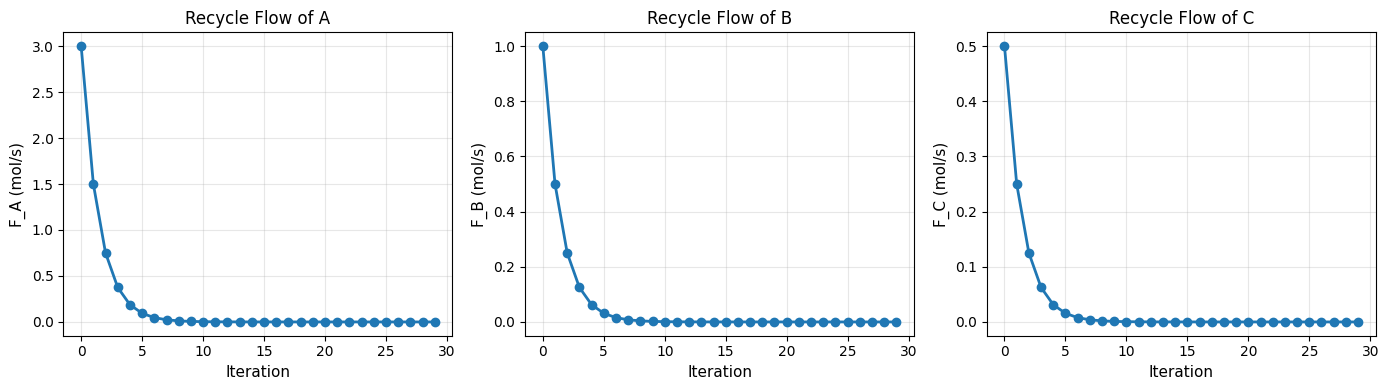


Final converged values:
  F_A = 0.0000 mol/s
  F_B = 0.0000 mol/s
  F_C = 0.0000 mol/s


In [12]:
# Technique 4: Visualize iteration trajectory
print("Debugging Technique 4: Visualize Iteration Trajectory")
print("=" * 50)

def solve_with_trajectory(fresh_feed, max_iter=30):
    """Solve and record the full trajectory."""
    
    cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")
    flash = Flash(flash_params, thermo=thermo)
    mixer = Mixer(species_order, thermo=thermo)
    
    trajectory = []
    x_curr = jnp.array([3.0, 1.0, 0.5, T_flash, P_flash])
    
    for i in range(max_iter):
        trajectory.append(x_curr.copy())
        
        recycle = make_stream(
            {"A": x_curr[0], "B": x_curr[1], "C": x_curr[2]},
            T=x_curr[3], P=x_curr[4],
        )
        
        reactor_inlet, _ = mixer(fresh_feed, recycle)
        reactor_outlet, _ = cstr(reactor_inlet, T_spec=360.0)
        liquid, vapor, _ = flash(reactor_outlet, T=T_flash, P=P_flash)
        
        g_curr = jnp.array([
            liquid["F_A"], liquid["F_B"], liquid["F_C"],
            liquid["T"], liquid["P"],
        ])
        
        residual = float(jnp.max(jnp.abs(g_curr - x_curr)))
        if residual < 1e-8:
            break
        
        # Simple damped update for visualization
        x_curr = 0.5 * x_curr + 0.5 * g_curr
    
    return jnp.stack(trajectory)

trajectory = solve_with_trajectory(fresh_feed)

# Plot the trajectory
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

species_names = ["A", "B", "C"]
for i, (ax, name) in enumerate(zip(axes, species_names)):
    ax.plot(trajectory[:, i], 'o-', linewidth=2, markersize=6)
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel(f'F_{name} (mol/s)', fontsize=11)
    ax.set_title(f'Recycle Flow of {name}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal converged values:")
print(f"  F_A = {float(trajectory[-1, 0]):.4f} mol/s")
print(f"  F_B = {float(trajectory[-1, 1]):.4f} mol/s")
print(f"  F_C = {float(trajectory[-1, 2]):.4f} mol/s")

## Part 4: Common Convergence Issues and Solutions

Here's a reference table for common issues:

In [13]:
issues_table = """
┌─────────────────────────────┬─────────────────────────────────┬─────────────────────────────────────┐
│ Symptom                     │ Likely Cause                    │ Solution                            │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Oscillating residuals       │ Under-damped iteration          │ Increase damping (0.3-0.5)          │
│                             │                                 │ Use Anderson acceleration           │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Very slow convergence       │ Poorly conditioned problem      │ Use Anderson acceleration           │
│                             │ Bad initial guess               │ Improve initialization              │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ NaN values                  │ log(0), sqrt(<0), 0/0           │ Add numerical guards                │
│                             │                                 │ Enable jax_debug_nans               │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Converges to zero flows     │ Poor initialization             │ Use physics-based initial guess     │
│                             │ Unstable steady state           │ Check reaction/separation coupling  │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Negative concentrations     │ Missing non-negativity guards   │ Add jnp.maximum(x, 0) guards        │
│                             │ Aggressive acceleration         │ Clip accelerated iterates           │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Flash doesn't converge      │ Two-phase region not exists     │ Check if T, P give valid VLE        │
│                             │ Near bubble/dew point           │ Move away from phase boundary       │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ CSTR temp. doesn't converge │ Strong exotherm + feedback      │ Increase temperature damping        │
│                             │ Multiple steady states          │ Try different initial temperatures  │
└─────────────────────────────┴─────────────────────────────────┴─────────────────────────────────────┘
"""

print("Common Convergence Issues and Solutions")
print(issues_table)

Common Convergence Issues and Solutions

┌─────────────────────────────┬─────────────────────────────────┬─────────────────────────────────────┐
│ Symptom                     │ Likely Cause                    │ Solution                            │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Oscillating residuals       │ Under-damped iteration          │ Increase damping (0.3-0.5)          │
│                             │                                 │ Use Anderson acceleration           │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ Very slow convergence       │ Poorly conditioned problem      │ Use Anderson acceleration           │
│                             │ Bad initial guess               │ Improve initialization              │
├─────────────────────────────┼─────────────────────────────────┼─────────────────────────────────────┤
│ NaN values           

## Part 5: Solver Parameter Tuning

The `Flowsheet.solve()` method accepts several parameters that can be tuned:

In [14]:
print("Flowsheet.solve() Parameters")
print("=" * 70)
print("""
Parameter         Default   Description
─────────────────────────────────────────────────────────────────────────
tol               1e-8      Convergence tolerance (max residual)
max_iter          100       Maximum iterations before giving up
acceleration      "anderson" Method: "none", "wegstein", or "anderson"
damping           0.5       Damping factor for "none" method (0 to 1)
anderson_depth    5         History depth for Anderson (higher = more memory)
use_initialization True     Use unit initialize() methods for initial guess
tear_initial      None      Custom initial guess for tear streams
""")

# Demonstrate parameter effects
print("\nEffect of Anderson Depth:")
print("-" * 40)

for depth in [2, 5, 10, 20]:
    result = solve_flowsheet(
        fresh_feed, 
        acceleration="anderson", 
        anderson_depth=depth,
        max_iter=50
    )
    print(f"  depth={depth:2d}: {result['iterations']:3d} iterations, " + 
          f"converged={result['converged']}")

Flowsheet.solve() Parameters

Parameter         Default   Description
─────────────────────────────────────────────────────────────────────────
tol               1e-8      Convergence tolerance (max residual)
max_iter          100       Maximum iterations before giving up
acceleration      "anderson" Method: "none", "wegstein", or "anderson"
damping           0.5       Damping factor for "none" method (0 to 1)
anderson_depth    5         History depth for Anderson (higher = more memory)
use_initialization True     Use unit initialize() methods for initial guess
tear_initial      None      Custom initial guess for tear streams


Effect of Anderson Depth:
----------------------------------------


  depth= 2:   2 iterations, converged=True


  depth= 5:   2 iterations, converged=True


  depth=10:   2 iterations, converged=True


  depth=20:   2 iterations, converged=True


In [15]:
# Demonstrate tolerance effects
print("\nEffect of Tolerance:")
print("-" * 40)

for tol in [1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    result = solve_flowsheet(
        fresh_feed, 
        acceleration="anderson",
        tol=tol,
        max_iter=100
    )
    print(f"  tol={tol:.0e}: {result['iterations']:3d} iterations, " +
          f"residual={result['final_residual']:.2e}")


Effect of Tolerance:
----------------------------------------


  tol=1e-04:   2 iterations, residual=0.00e+00


  tol=1e-06:   2 iterations, residual=0.00e+00


  tol=1e-08:   2 iterations, residual=0.00e+00


  tol=1e-10:   2 iterations, residual=0.00e+00


  tol=1e-12:   2 iterations, residual=0.00e+00


## Part 6: Gradient Verification

When gradients through converged solutions look wrong, verify them:

In [16]:
print("Gradient Verification")
print("=" * 50)

# For gradient verification, we need a JIT-compatible solver
# The manual solver above uses Python float() which isn't traceable
# Instead, we'll demonstrate gradient checking on a simpler flowsheet function

def simple_cstr_objective(reactor_volume):
    """Compute product C flow from a single CSTR (no recycle)."""
    cstr_params = CSTRParams(
        V=reactor_volume,
        rate_fn=rate_function,
        stoich=stoichiometry,
        rate_params=rate_params,
        species_order=species_order,
        dH_rxn=jnp.array([-40000.0, -40000.0]),
    )
    cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")
    
    # Simple inlet
    inlet = make_stream({"A": 10.0, "B": 0.0, "C": 0.0}, T=300.0, P=P_flash)
    outlet, _ = cstr(inlet, T_spec=360.0)
    
    return outlet["F_C"]

# Compute gradient with autodiff
V_base = 10.0  # 10 m³ reactor
grad_autodiff = jax.grad(simple_cstr_objective)(jnp.array(V_base))

# Verify with finite differences
eps = 1e-5
f_plus = simple_cstr_objective(jnp.array(V_base + eps))
f_minus = simple_cstr_objective(jnp.array(V_base - eps))
grad_fd = (f_plus - f_minus) / (2 * eps)

print(f"dF_C/dV at V={V_base} m³:")
print(f"  Autodiff:          {float(grad_autodiff):.6f}")
print(f"  Finite difference: {float(grad_fd):.6f}")
print(f"  Relative error:    {abs(float(grad_autodiff - grad_fd) / float(grad_fd + 1e-10))*100:.4f}%")

print("\nNote: For flowsheets with recycles, use optimistix.implicit_jvp")
print("to get gradients through the converged solution.")

Gradient Verification


dF_C/dV at V=10.0 m³:
  Autodiff:          0.000446
  Finite difference: 0.000446
  Relative error:    0.0000%

Note: For flowsheets with recycles, use optimistix.implicit_jvp
to get gradients through the converged solution.


In [17]:
# Using JAX's built-in gradient checker
print("\nUsing jax.test_util.check_grads():")
print("-" * 40)

from jax.test_util import check_grads

# Test gradient correctness on the simple CSTR objective
try:
    check_grads(simple_cstr_objective, (jnp.array(10.0),), order=1, modes=['rev'], eps=1e-4)
    print("Gradient check PASSED")
except AssertionError as e:
    print(f"Gradient check FAILED: {e}")

print("\nTip: Use check_grads() to verify autodiff gradients match finite differences.")


Using jax.test_util.check_grads():
----------------------------------------


Gradient check PASSED

Tip: Use check_grads() to verify autodiff gradients match finite differences.


## Summary: Best Practices for Robust Convergence

### 1. Choose the Right Acceleration Method
- **Simple problems**: `"none"` with damping 0.3-0.7
- **Moderate problems**: `"wegstein"` 
- **Difficult problems**: `"anderson"` (usually the best default)

### 2. Initialize Well
- Use physics-based estimates (reaction conversions, flash splits)
- Start from a nearby solved case if available
- Avoid zero or very small initial flows

### 3. Add Numerical Guards
- `jnp.maximum(x, 1e-10)` before `log(x)` or `1/x`
- `jnp.clip()` for bounded quantities (mole fractions, temperatures)
- Enable `jax_debug_nans` during development

### 4. Debug Systematically
- Test units individually before combining
- Visualize residual trajectories
- Use `jax.debug.print()` inside JIT functions
- Simplify the problem to isolate issues

### 5. Tune Tolerances Appropriately
- Tighter tolerance = more iterations but more accurate gradients
- For gradient-based optimization, use at least `tol=1e-8`
- For quick exploration, `tol=1e-6` is often sufficient

In [18]:
print("\nKey Takeaways:")
print("─" * 60)
print("""
1. Anderson acceleration is usually the best choice for recycles
2. Good initialization can reduce iterations by 50% or more
3. Numerical guards prevent NaN/Inf from propagating
4. Test units individually when debugging
5. Verify gradients with finite differences when in doubt
""")


Key Takeaways:
────────────────────────────────────────────────────────────

1. Anderson acceleration is usually the best choice for recycles
2. Good initialization can reduce iterations by 50% or more
3. Numerical guards prevent NaN/Inf from propagating
4. Test units individually when debugging
5. Verify gradients with finite differences when in doubt

